## Modèle de base - Random Forest après update preprocessing

In [1]:
import os
import sys
parent_dir = os.path.abspath('..')
sys.path.append(parent_dir) #set root to path so src visible

# Import des librairies

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Traitement des emails
from src.model.topicModeling import EmailBERTopicNoLeakagePipeline

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor
from src.utils.TransformData import dataframe_merge, code_insee_from_communes_as_dict

## ML + evaluation
!python -m spacy download fr_core_news_md
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold

/home/onyxia/work/Alptis-churn-prediction/src/model/topicModeling.py:684: SyntaxWarning: invalid escape sequence '\W'
  if re.fullmatch(r"[_\W\d]+", lemma_no_acc):
/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 58.5 MB/s  0:00:00m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')


In [2]:
#1. Pre-process training data (scaler and encoder are saved during this process)
train_processor = DataProcessor(mode="training")
df_train = train_processor.run(optional_encoding=True, optional_normalisation=False)  #fit training set and save arguments (scaler, ordinal map, target_encoding_maps, ...)

#2. Pre-process test data (by using the same scaler/encoder fitted on training dataset)
test_processor = DataProcessor(mode="validation")

#  HERE:  Reuse the same pre-processor fitted on training dataset (so no data-leakage with target-encoding, normalisation...)
test_processor.global_means = train_processor.global_means
test_processor.target_encoding_maps = train_processor.target_encoding_maps
test_processor.fixed_categories_fitted = train_processor.fixed_categories_fitted
test_processor.ordinal_maps          = train_processor.ordinal_maps
test_processor.encoded_columns       = train_processor.encoded_columns
test_processor.scaler                = train_processor.scaler
test_processor.normalized_columns    = train_processor.normalized_columns #only if optional_normalisation = True

df_test = test_processor.run_transform(optional_encoding=True, optional_normalisation=False) #pre-process test data using same args 

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_code_postal', 'client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'client_nps_date_reponse_n_moins1_jours', 'client_nps_date_reponse_n_jours']
INFO:src.data_processing.data_processing:Columns that are Fixed-category one-hot encoded: ['courtier_segmentation_interne']
INFO:src.data_processing.data_processing:Columns that are One-hot encoded: ['client_mode_paiement', 'courtier_reseau_courtage', 'courtier_type_commission']
INFO:src.data_processing.data_processing:Columns that are Target encoded: ['client_ro_souscripteur', 'client_produit', 'client_g

In [3]:
#3. Preprocess et dit du BERTOPIC sur le train
emailPreprocessor = EmailBERTopicNoLeakagePipeline()
_, _, _, email_training_dataset, _ = data_loading("training")
email_training_dataset["objet_contenu"] = email_training_dataset["interaction_texte_mail"] 
email_train, topic_train = emailPreprocessor.build_dataset_split(
    df_split=email_training_dataset,
    email_mode="fit"
)


#4. Jointure à la base de train


#5. Preprocess et transform du BERTOPIC sur les données de validation
_, _, _, email_validation_dataset, _ = data_loading("validation")
email_validation_dataset["objet_contenu"] = email_validation_dataset["interaction_texte_mail"] 
email_validation, topic_validation = emailPreprocessor.build_dataset_split(
    df_split=email_validation_dataset,
    email_mode="transform"
)


#6. Jointure à la base de validation

INFO:sentence_transformers.base.model:No device provided, using cpu
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/paraphrase-multilingual-M

entame du cleaning complet avec les regex et spacy
Fin du cleaning complet avec les regex et spacy


Batches: 100%|██████████| 377/377 [38:12<00:00,  6.08s/it] 
2026-04-22 01:01:45,172 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 01:04:56,064 - BERTopic - Dimensionality - Completed ✓
2026-04-22 01:04:56,068 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 01:05:04,725 - BERTopic - Cluster - Completed ✓
2026-04-22 01:05:04,752 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 01:05:07,631 - BERTopic - Representation - Completed ✓


début de préparation des lignesemail
entame du cleaning complet avec les regex et spacy
Fin du cleaning complet avec les regex et spacy
début de l'encodage des emails


2026-04-22 06:14:07,464 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.


début de la transformation du topic modelling


2026-04-22 06:14:35,070 - BERTopic - Dimensionality - Completed ✓
2026-04-22 06:14:35,072 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-22 06:14:38,047 - BERTopic - Cluster - Completed ✓


In [4]:
# Jointure du dataset de train
columns_de_topic = [c for c in email_train.columns.tolist() if "topic" in c]
del columns_de_topic[2]
columns_de_topic.append("client_code")

## Colonnes de one ot encoding ( à remplacer par du 0 si pas d'interaction)
columns_topic_count = [c for c in columns_de_topic if "count" in c]
columns_props_count = [c for c in columns_de_topic if "prop" in c]

## Colonnes à remplacer par 0 si pas d'interaction
columns_topic_0 = ["n_topics_distinct", "mean_topic_confidence"]

## Colonnes à remplacer par -99 si pas d'interaction
columns_topic_99 = ["dominant_topic", "latest_topic"]

## Merge df train
df_train_email = pd.merge(
    left=df_train,
    right=email_train[columns_de_topic],
    how="left",
    on="client_code"
)

## Imputer les lignes sans valeur
for elem in columns_topic_count + columns_props_count +  columns_topic_0:
    df_train_email[elem] = df_train_email[elem].fillna(0)

for elem in columns_topic_99:
    df_train_email[elem] = df_train_email[elem].fillna(-99)

df_train_email[columns_de_topic].isna().sum()

n_topics_distinct        0
mean_topic_confidence    0
topic_count_0            0
topic_count_1            0
topic_count_2            0
                        ..
topic_prop_427           0
topic_prop_428           0
dominant_topic           0
latest_topic             0
client_code              0
Length: 864, dtype: int64

In [5]:
columns_de_topic

['n_topics_distinct',
 'mean_topic_confidence',
 'topic_count_0',
 'topic_count_1',
 'topic_count_2',
 'topic_count_3',
 'topic_count_4',
 'topic_count_5',
 'topic_count_6',
 'topic_count_7',
 'topic_count_8',
 'topic_count_9',
 'topic_count_10',
 'topic_count_11',
 'topic_count_12',
 'topic_count_13',
 'topic_count_14',
 'topic_count_15',
 'topic_count_16',
 'topic_count_17',
 'topic_count_18',
 'topic_count_19',
 'topic_count_20',
 'topic_count_21',
 'topic_count_22',
 'topic_count_23',
 'topic_count_24',
 'topic_count_25',
 'topic_count_26',
 'topic_count_27',
 'topic_count_28',
 'topic_count_29',
 'topic_count_30',
 'topic_count_31',
 'topic_count_32',
 'topic_count_33',
 'topic_count_34',
 'topic_count_35',
 'topic_count_36',
 'topic_count_37',
 'topic_count_38',
 'topic_count_39',
 'topic_count_40',
 'topic_count_41',
 'topic_count_42',
 'topic_count_43',
 'topic_count_44',
 'topic_count_45',
 'topic_count_46',
 'topic_count_47',
 'topic_count_48',
 'topic_count_49',
 'topic_coun

In [6]:
# Jointure du dataset de test
columns_de_topic = [c for c in email_validation.columns.tolist() if "topic" in c]
del columns_de_topic[2]
columns_de_topic.append("client_code")

## Colonnes de one ot encoding ( à remplacer par du 0 si pas d'interaction)
columns_topic_count = [c for c in columns_de_topic if "count" in c]
columns_props_count = [c for c in columns_de_topic if "prop" in c]

## Colonnes à remplacer par 0 si pas d'interaction
columns_topic_0 = ["n_topics_distinct", "mean_topic_confidence"]

## Colonnes à remplacer par -99 si pas d'interaction
columns_topic_99 = ["dominant_topic", "latest_topic"]

## Merge df train
df_validation_email = pd.merge(
    left=df_test,
    right=email_validation[columns_de_topic],
    how="left",
    on="client_code"
)

## Imputer les lignes sans valeur
for elem in columns_topic_count + columns_props_count +  columns_topic_0:
    df_validation_email[elem] = df_validation_email[elem].fillna(0)

for elem in columns_topic_99:
    df_validation_email[elem] = df_validation_email[elem].fillna(-99)

df_validation_email[columns_de_topic].isna().sum()


n_topics_distinct        0
mean_topic_confidence    0
topic_count_0            0
topic_count_1            0
topic_count_2            0
                        ..
topic_prop_427           0
topic_prop_428           0
dominant_topic           0
latest_topic             0
client_code              0
Length: 864, dtype: int64

_____

**Analyse descriptive des topics**

In [7]:
#  Useful functions
#####################

## Comparaison des topics par classe et affichage des mots des topics associés à la classe 1
def topic_class_summary(df, topic_col="topic", class_col="target_resiliation_6mois"):
    tab = pd.crosstab(df[topic_col], df[class_col])

    # sécuriser si colonnes absentes
    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab[[0, 1]]
    tab.columns = ["class_0", "class_1"]

    tab["share_class_0"] = round(100 * tab["class_0"] / tab["class_0"].sum(), 3)
    tab["share_class_1"] = round(100 * tab["class_1"] / tab["class_1"].sum(), 3)
    tab["diff_1_minus_0"] = round( tab["share_class_1"] - tab["share_class_0"], 3)

    return tab.sort_values("diff_1_minus_0", ascending=False)


## Word cloud des mots d'un topic donné
!pip install wordcloud
!pip install matplotlib
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_topic_wordcloud(topic_model, topic_id, title=None):
    topic_words = topic_model.get_topic(topic_id)

    if topic_words is None:
        print(f"Aucun mot trouvé pour le topic {topic_id}")
        return

    freqs = {word: weight for word, weight in topic_words}

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title or f"Topic {topic_id}")
    plt.show()


# Visulaliser des exemple d'email pour la classe des churns en fonction du topic
def show_example_emails(df, topic_id, class_value=None, text_col="objet_contenu", n=8):
    sub = df[df["topic"] == topic_id].copy()
    if class_value is not None:
        sub = sub[sub["target_resiliation_6mois"] == class_value]

    examples = sub[text_col].dropna().sample(n).tolist()
    for i, txt in enumerate(examples, 1):
        print(f"\n--- Exemple {i} ---\n{txt[:1000]}")

In [8]:
# Jointure des emails et du fichier de portefeuille

df_portefeuille, _, _, _, _ = data_loading("training")
df_portefeuille = df_portefeuille[["client_code", "target_resiliation_6mois"]]
central, left, right = dataframe_merge(df_portefeuille, topic_train, id_1="client_code", id_2="client_code")

In [9]:
# Tableau de répartition des topics selon la classe de client
 
pd.set_option('display.max_rows', 20)
topic_summary = topic_class_summary(central)
topic_summary.head(20)

,class_0,class_1,share_class_0,share_class_1,diff_1_minus_0
topic,,,,,
5,1730,493,2.176,2.929,0.753
76,18,116,0.023,0.689,0.666
11,506,204,0.637,1.212,0.575
62,64,104,0.081,0.618,0.537
13,477,162,0.600,0.962,0.362
155,19,63,0.024,0.374,0.350
1,2828,648,3.558,3.850,0.292
168,25,52,0.031,0.309,0.278
249,7,47,0.009,0.279,0.270


In [ ]:
# Topic 5 - Résiliation avec motif d'augmentation de cotisation
show_example_emails(
    df=central,
    topic_id=5,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 Refus de résiliation xxpj1 ECRIT CLIENT xxobj Dossier VERT Marc réf :  flag_client_  xxcont     Merci de bien vouloir reporter la date d'effet de ce dossier pour le  flag_date_ , et ceci suite au refus de résiliation de l'ancienne mutuelle. Comptant sur votre collaboration,

--- Exemple 2 ---
xxpj0  xxobj TR:  flag_client_  - Madame flag_nom_   xxcont    Je vous remercie de bien vouloir nous transmettre le mandat de résiliation pour ce dossier. Pour toute question, je me tiens, ainsi que toute l’équipe SOLAE à votre disposition. Téléphone :  flag_phone_  ( flag_time_  –  flag_time_ ) Mail :  flag_mail_ <mailto: flag_mail_   

--- Exemple 3 ---
xxpj0 DOC130223 xxpj1 BA_edited xxpj2 Ecrit xxpj3 SEPA_edited xxpj4 Resiliation_35322529 xxobj  flag_client_  flag_nom_   190645146 xxcont      Merci de reporter le contrat au  flag_date_  suite au refus de resil dapivia pour cause délai non respecté

--- Exemple 4 ---
xxpj0 Courrier de résiliation flag_nom_  xxobj Résil

In [22]:
# Topic 76 - Résiliation avec motif d'augmentation de cotisation
show_example_emails(
    df=central,
    topic_id=76,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 9312883210 xxobj  flag_client_  DI flag_localisation_   /  RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  9312883210   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
xxpj0 6697265529 xxobj  flag_client_  PALADE COLETTE  /  RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  6697265529   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
xxpj0 6285314

In [39]:
# Topic 143 - Remboursement de cure thermale
show_example_emails(
    df=central,
    topic_id=143,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 8488152853 xxobj  flag_client_  flag_localisation_   /  RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  8488152853   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
xxpj0 9415379052 xxobj  flag_client_  flag_nom_   /  RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  9415379052   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
xxpj0 7170418852 xxo

In [44]:
# Topic 10 - Radiation en cours d'année
show_example_emails(
    df=central,
    topic_id=10,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 IMG_20231025_161823 xxobj Client  flag_client_  xxcont   Pour calcul remboursement sur devis dépassements d'honoraires joint.

--- Exemple 2 ---
xxpj0 Numérisation_20231028 xxpj1 Numérisation_20231028 (3) xxobj HONORAIRES xxcont   flag_nom_  72O flag_localisation_   flag_cp_  flag_nom_ R N° Adhérent :  flag_client_   Vous trouverez en pièces jointes, les factures d'honoraires.

--- Exemple 3 ---
xxpj0  xxobj  xxcont   ‌bjr ma femme a ete opere du cataracte le  flag_date_ avec un depassement d honoraire de  flag_amount_  vous m avez rembourse  flag_amount_  elle fait le 2eme oeil le16  flag_date_ avec le meme depassement d honoraire et vous me rembourse que  flag_date_  porquoi merci de recevoir une reponse de votre part

--- Exemple 4 ---
xxpj0 doc_2023112811132415 xxobj ADHERENT  flag_client_  flag_nom_  xxcont    Vous trouverez en PJ 2 notes d'honoraires pour gestion des remboursements.

--- Exemple 5 ---
xxpj0 Pedicure_C flag_nom_ _ flag_nom_ ssale xxobj rem

In [46]:
# Topic 316 - Résiliation infra annuelle - mail automatique
show_example_emails(
    df=central,
    topic_id=316,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 4764065042 xxobj  flag_client_  / RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  4764065042   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
xxpj0 3822116734 xxobj  flag_client_  flag_nom_   /  RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  3822116734   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
xxpj0 4015604202 xxobj  flag_client_  flag

In [50]:
# Topic 362 - Facture pour remboursement en général
show_example_emails(
    df=central,
    topic_id=362,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 7793922405 xxobj  flag_client_  flag_localisation_  flag_nom_   /  flag_localisation_  xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7793922405   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
xxpj0 4336058636 xxobj  flag_client_  flag_localisation_   /  flag_localisation_  xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  4336058636   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les piè

In [36]:
# Topic 1 - Offre de fidelisation - 1 mois offert
show_example_emails(
    df=central,
    topic_id=1,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 20230627_185653 xxobj Absence de contrat xxcont   Je reçois ce courrier de la sécurité sociale. Pouvez-vous me confirmer que la télétransmission soit bien activée. Me flag_nom_ , Adhérente:  flag_client_  Dans l'attente de votre réponse recevez flag_nom_  mes respectueuses salutations. Me flag_nom_ 

--- Exemple 2 ---
xxpj0  xxobj flag_nom_   flag_client_  DEMANDE DE REMBOURSEMENT  /  PROBLEME TELETRANSMISSION KINE xxcont     *Dossier flag_nom_   flag_client_ *  Mes clients vous ont transmis des décomptes sécu concernant des séances de kiné, le  flag_date_  et aujourd'hui. Merci de bien vouloir faire le nécessaire rapidement. Aussi, pour quelle raison la télétransmission ne fonctionne pas concernant les séances de kiné?

--- Exemple 3 ---
xxpj0 IMG_20230718_135328 xxobj Remboursement xxcont   Veuillez trouver ci-joint facture acquittée d'avance merci Envoyé depuis mon téléphone

--- Exemple 4 ---
xxpj0 deìcompte flag_nom_  xxpj1 attestation de droits flag_nom_ 

In [37]:
# Topic 168 - Offre de fidélisation - mois offert
show_example_emails(
    df=central,
    topic_id=168,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 5941026636 xxobj  flag_client_  flag_nom_   /  RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  5941026636   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
xxpj0 7639599074 xxobj  flag_client_  flag_nom_  / RIA xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7639599074   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
xxpj0 4783032224 xxobj  flag_cl

In [38]:
# Topic 249 - Participation de la sécurité sociale dans les remboursement
show_example_emails(
    df=central,
    topic_id=249,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 3406749965 xxobj  flag_client_  flag_localisation_   /  flag_localisation_  xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  3406749965   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
xxpj0 2173304059 xxobj  flag_client_  flag_localisation_   /  flag_localisation_  xxcont    Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  2173304059   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes

In [19]:
# Topic 8 - Demande de remboursement cas général
show_example_emails(
    df=central,
    topic_id=8,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0 CamScanner 28-11-2023 09.27 xxobj Devis anesthésie xxcont   Veuillez trouver ci-joint le devis d'anesthésie qui nous a été remis hier à mon époux flag_nom_ . L'intervention à lieu  flag_date_  à la clinique des conti flag_localisation_   flag_cp_  Numéro d'adhérent est le  flag_client_ 

--- Exemple 2 ---
xxpj0 Screenshot_2023- flag_phone_ -086_com.miui.gallery xxobj Documents d honoraires chirurgien xxcont  

--- Exemple 3 ---
xxpj0 facture depassement honoraire xxpj1 honoraire paye xxobj remboursement intervention chirurgicale URGENT xxcont   Comme suite à notre entretien téléphonique de ce jour, veillez trouver ci-joint les factures demandées. Je reste disponible, je suis actuellement en métropole

--- Exemple 4 ---
xxpj0 IMG20230710154948 xxpj1 IMG20230710154925 xxobj Devis dépassements d honoraires xxcont   Veuillez trouver ci-joint 2 devis anesthésie pour opération cataracte du 25/7 et  flag_date_  comme indiqué voir pour les dépassements d honoraires.Les

In [23]:
# Topic 19 - RIA message automatique
show_example_emails(
    df=central,
    topic_id=169,
    class_value=1,
    n=10
)


--- Exemple 1 ---
xxpj0  xxobj report date effet  flag_client_  flag_localisation_  xxcont    pouvez vous reporter la date d'effet du contrat en référence *au  flag_date_ .*

--- Exemple 2 ---
xxpj0 mothiron xxobj Fwd: report contrat xxcont    Demande de report : Code courtier :  flag_cp_  Nom prénom : flag_nom_  N° adhérent :  flag_client_   Je vous envoie en pièce jointe le certificat d'affiliation de la cliente chez sa mutuelle jusqu'au  flag_date_ . Merci de bien vouloir faire le nécessaire et reporter son contrat pour le  flag_date_ .  

--- Exemple 3 ---
xxpj0  xxobj Adhérent individuel  flag_client_  flag_nom_  xxcont    Merci de bien vouloir reporter la date d’effet du contrat de Mr flag_nom_   flag_client_  au 4 mai. Voir mail du courtier ci-dessous.  

--- Exemple 4 ---
xxpj0 mothiron xxobj Fwd: report contrat xxcont    Demande de report : Code courtier :  flag_cp_  Nom prénom : flag_nom_  N° adhérent :  flag_client_   Je vous envoie en pièce jointe le certificat d'affiliati

In [24]:
# Récupération du top 10 des topics et construction d'un dataset avec ceux-c
topics_important = [5] # [52, 3] --> 0.7569 # [52] --> 0.7589 #[3] --> 0.7589 # [19, 163, 141, 3]   # Ensemble [3, 19, 141, 163, 9, 151, 87, 21, 8, 19]
topics_important = [f"topic_count_{c}" for c in topics_important]

#========================================

# Constitution du nouveau dataset de train sur la base de ces topics
## Jointure du dataset de train avec filtre des topics
columns_de_topic = topics_important
columns_de_topic.append("client_code")


## Colonnes de one ot encoding ( à remplacer par du 0 si pas d'interaction)
columns_topic_count = [c for c in columns_de_topic if "count" in c]

## Merge df train
df_train_email = pd.merge(
    left=df_train,
    right=email_train[columns_de_topic],
    how="left",
    on="client_code"
)

## Imputer les lignes sans valeur
for elem in columns_topic_count :
    df_train_email[elem] = df_train_email[elem].fillna(0)

print(f"{df_train_email[columns_de_topic].sum()}")

#==========================================
# Constitution du nouveau dataset de validation sur la base de ces topics
## Jointure du dataset de train avec filtre des topics
columns_de_topic = topics_important


## Colonnes de one ot encoding ( à remplacer par du 0 si pas d'interaction)
columns_topic_count = [c for c in columns_de_topic if "count" in c]

## Merge df train
df_validation_email = pd.merge(
    left=df_test,
    right=email_validation[columns_de_topic],
    how="left",
    on="client_code"
)

## Imputer les lignes sans valeur
for elem in columns_topic_count:
    df_validation_email[elem] = df_validation_email[elem].fillna(0)

print(f"{df_validation_email[columns_de_topic].sum()}")

topic_count_5    2.223000e+03
client_code      1.727996e+12
dtype: float64
topic_count_5    6.910000e+02
client_code      5.193961e+11
dtype: float64


_________

**Random Forest avec données textuelles**

In [25]:
# check différences de colonnes
col_train = df_train_email.columns.to_list()
col_test = df_validation_email.columns.to_list()

diff_train = list(set(col_train)-set(col_test))
diff_test = list(set(col_test)-set(col_train))
print(f"Dans train et pas dans test : {diff_train}")
print(f"Dans Test et pas dans train : {diff_test}")

Dans train et pas dans test : []
Dans Test et pas dans train : []


In [26]:
# Définition des X de train et de test et des y de train et de test
X_train = df_train_email.drop(['target_resiliation_6mois', 'client_code'], axis=1)
y_train = df_train_email['target_resiliation_6mois']
X_test = df_validation_email.drop(['target_resiliation_6mois', 'client_code'], axis=1)
y_test = df_validation_email['target_resiliation_6mois']

In [28]:
# Modèle avec recherche des meilleurs hyperparamètre

## Initialiser un rf
rf = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

## Initialiser les paramètres du gridsearch
hp_space = {
    #"n_estimators": [1000],
    #"max_depth": [2, 10, 15, 20],
    #"max_features": ["sqrt", "log2"]
    'n_estimators': [857], 'max_depth': [17], 'min_samples_leaf': [19], 'min_samples_split': [3], 'max_features': [0.3]
}

## Instancier le gridsearch
grid = GridSearchCV(
    estimator= rf,
    param_grid=hp_space,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5)
)

## Ajustement sur jeu d'entrainement
models = grid.fit(X_train, y_train)

## Récupération du meilleur model
best_model = grid.best_estimator_
print(f"Les meilleurs paramètres dans l'espace des hyperparamètres : {grid.best_params_} \n")

## extrapolation sur données de test
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

## Collecte des métriques d'évalution
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
recall = recall_score(y_true=y_test, y_pred=y_pred_test)
f1 = f1_score(y_true=y_test, y_pred=y_pred_test)
precision = precision_score(y_true=y_test, y_pred=y_pred_test)
roc_auc = roc_auc_score(y_true=y_test, y_score=y_proba_test)

print(f"Score AUC du modèle sur le jeu de test : {roc_auc:.4f}\n")

## Rapport de classification
print("=========== Rapport Random Forest (test) ===========\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print("===================================================\n")

Les meilleurs paramètres dans l'espace des hyperparamètres : {'max_depth': 17, 'max_features': 0.3, 'min_samples_leaf': 19, 'min_samples_split': 3, 'n_estimators': 857} 

Score AUC du modèle sur le jeu de test : 0.7757

=========== Rapport Random Forest (test) ===========

              precision    recall  f1-score   support

           0       0.93      0.88      0.90     34549
           1       0.28      0.43      0.34      3900

    accuracy                           0.83     38449
   macro avg       0.61      0.65      0.62     38449
weighted avg       0.87      0.83      0.85     38449




L'aire en dessous de la courbe ROC est de 0.7757


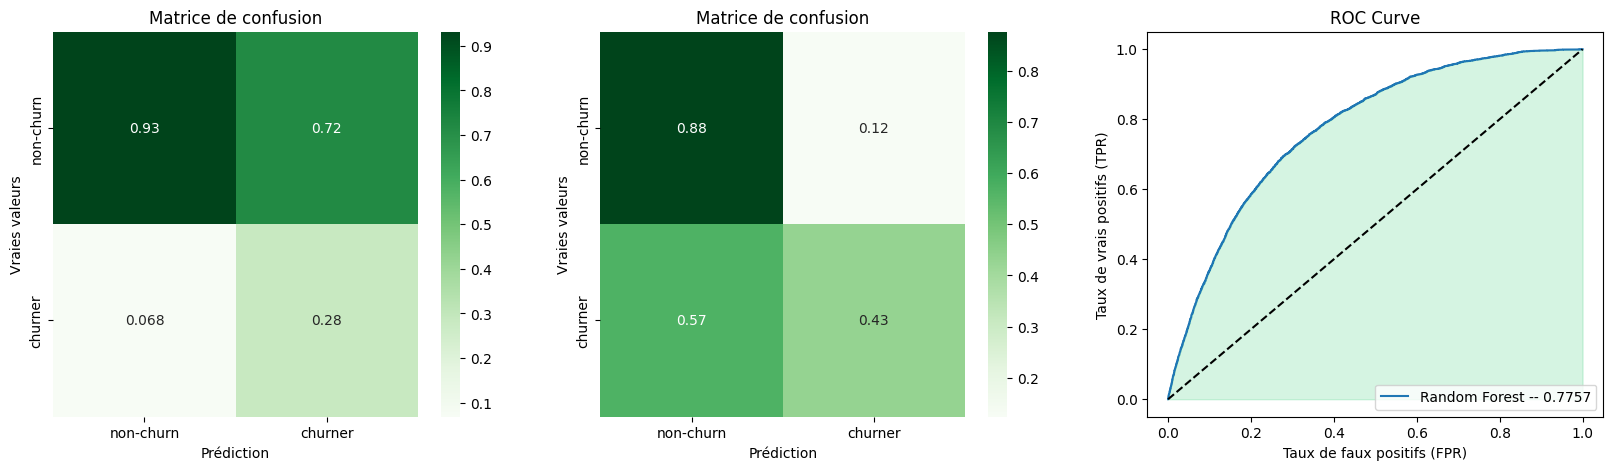

In [29]:
# Matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm1 = confusion_matrix(y_test, y_pred_test, normalize='pred')
sns.heatmap(cm1, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[0])
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Vraies valeurs')
axes[0].set_title("Matrice de confusion")

cm2 = confusion_matrix(y_test, y_pred_test, normalize='true')
sns.heatmap(cm2, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[1])
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Vraies valeurs')
axes[1].set_title("Matrice de confusion")

fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_proba_test)
axes[2].plot(fpr, tpr, label=f"Random Forest -- {roc_auc:.4f}")
axes[2].set_xlabel("Taux de faux positifs (FPR)")
axes[2].set_ylabel("Taux de vrais positifs (TPR)")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
axes[2].legend(loc='lower right', fontsize=10)
axes[2].set_title("ROC Curve")

print(f"L'aire en dessous de la courbe ROC est de {round(roc_auc, 4)}")
plt.show()

_____

**Random Forest sans les emails**

In [ ]:
# Définition des X de train et de test et des y de train et de test
X_train = df_train.drop(['target_resiliation_6mois', 'client_code'], axis=1)
y_train = df_train['target_resiliation_6mois']
X_test = df_test.drop(['target_resiliation_6mois', 'client_code'], axis=1)
y_test = df_test['target_resiliation_6mois']

In [30]:
# Modèle avec recherche des meilleurs hyperparamètre

## Initialiser un rf
rf = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

## Initialiser les paramètres du gridsearch
hp_space = {
    #"n_estimators": [1000],
    #"max_depth": [2, 10, 15, 20],
    #"max_features": ["sqrt", "log2"]
    'n_estimators': [857], 'max_depth': [17], 'min_samples_leaf': [19], 'min_samples_split': [3], 'max_features': [0.3]
}

## Instancier le gridsearch
grid = GridSearchCV(
    estimator= rf,
    param_grid=hp_space,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5)
)

## Ajustement sur jeu d'entrainement
models = grid.fit(X_train, y_train)

## Récupération du meilleur model
best_model = grid.best_estimator_
print(f"Les meilleurs paramètres dans l'espace des hyperparamètres : {grid.best_params_} \n")

## extrapolation sur données de test
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

## Collecte des métriques d'évalution
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
recall = recall_score(y_true=y_test, y_pred=y_pred_test)
f1 = f1_score(y_true=y_test, y_pred=y_pred_test)
precision = precision_score(y_true=y_test, y_pred=y_pred_test)
roc_auc = roc_auc_score(y_true=y_test, y_score=y_proba_test)

print(f"Score AUC du modèle sur le jeu de test : {roc_auc:.4f}\n")

## Rapport de classification
print("=========== Rapport Random Forest (test) ===========\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print("===================================================\n")

Les meilleurs paramètres dans l'espace des hyperparamètres : {'max_depth': 17, 'max_features': 0.3, 'min_samples_leaf': 19, 'min_samples_split': 3, 'n_estimators': 857} 

Score AUC du modèle sur le jeu de test : 0.7757

=========== Rapport Random Forest (test) ===========

              precision    recall  f1-score   support

           0       0.93      0.88      0.90     34549
           1       0.28      0.43      0.34      3900

    accuracy                           0.83     38449
   macro avg       0.61      0.65      0.62     38449
weighted avg       0.87      0.83      0.85     38449




L'aire en dessous de la courbe ROC est de 0.7565


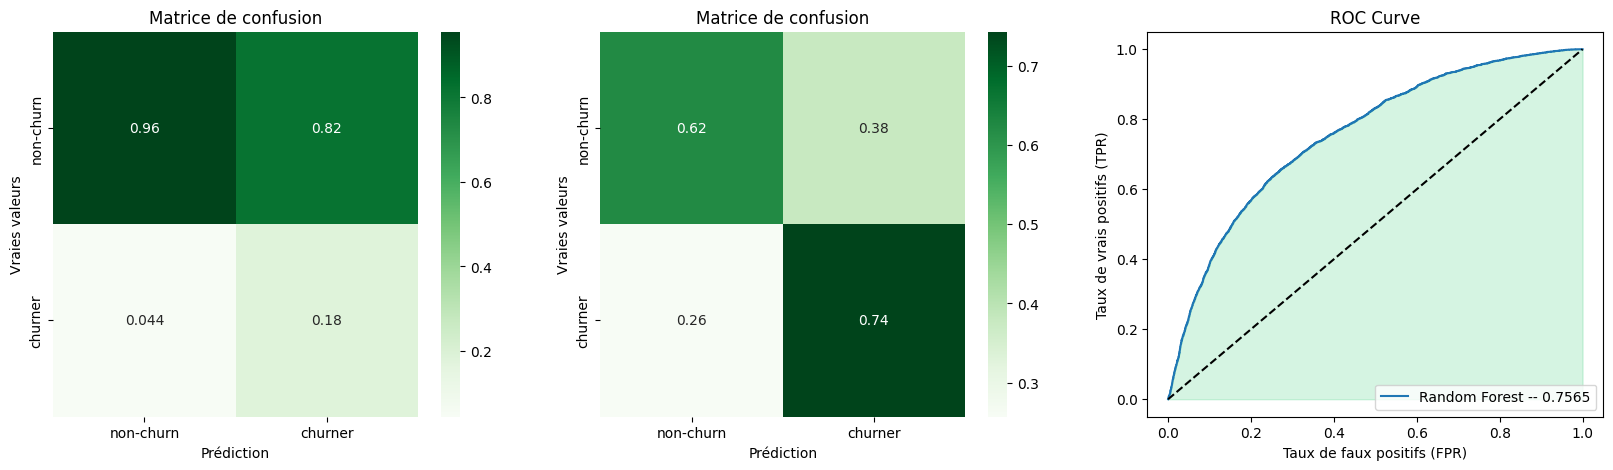

In [ ]:
# Matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm1 = confusion_matrix(y_test, y_pred_test, normalize='pred')
sns.heatmap(cm1, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[0])
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Vraies valeurs')
axes[0].set_title("Matrice de confusion")

cm2 = confusion_matrix(y_test, y_pred_test, normalize='true')
sns.heatmap(cm2, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[1])
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Vraies valeurs')
axes[1].set_title("Matrice de confusion")

fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_proba_test)
axes[2].plot(fpr, tpr, label=f"Random Forest -- {roc_auc:.4f}")
axes[2].set_xlabel("Taux de faux positifs (FPR)")
axes[2].set_ylabel("Taux de vrais positifs (TPR)")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
axes[2].legend(loc='lower right', fontsize=10)
axes[2].set_title("ROC Curve")

print(f"L'aire en dessous de la courbe ROC est de {round(roc_auc, 4)}")
plt.show()